<a href="https://colab.research.google.com/github/Maxwell553/Beat2048/blob/main/GBM1_Find_Spidey.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GBM 1: Machine Learning - Mission: Find Spidey 🕷️
## Presented by AI Community

**Welcome! No prior coding, math, or AI experience is needed.**
Whether you are an art major, biology major, or a computer science freshman, this workshop is designed for you.

**Important:** This dataset is **synthetically generated** for teaching. The sightings, incidents, and witnesses are simulated, and the geography uses simplified boundaries (see the [publisher README](https://www.kaggle.com/datasets/umuttuygurr/spidey-tracker-spiderman-dataset)). Treat results as practice with ML methods—not a real investigation of a real person.

**Story:** The CEO has hired a team of ML Engineers to develop a machine learning algorithm to find Spider-Man’s home location. Your job is to follow the CEO’s orders and make a machine learning model to guess where Spider-Man’s home location is. The Spidey Tracker has already collected the dataset for you.

**Your mission:** We have a giant list of Spider-Man sighting reports around the city. We will act like digital detectives and use Machine Learning for two **separate** demos (the classifier does **not** filter the clustering data):
1. **Predicting report verification** — learn patterns that separate `verified` vs `not verified` labels in the dataset.
2. **Where might Spidey's secret home base be?** — group late-night locations to find candidate hotspots.

**Key Links to Reference:**

Dataset:
https://www.kaggle.com/datasets/umuttuygurr/spidey-tracker-spiderman-dataset

Accompanying Slideshow:
https://canva.link/5mzhlnyaws9pua1


## Getting started in Google Colab & Importing Libraries/Datasets

**Using this notebook:**
Run each code cell from top to bottom by clicking ▶ or pressing **Shift + Enter**.

**Let's begin!** Run the next two code cells. The first one loads our digital tools, and the second one downloads our Spiderman sightings evidence folder.

In [ ]:
# 🕷️ Workshop Setup (importing libraries)

import importlib.util, subprocess, sys
packages = {'numpy': 'numpy', 'pandas': 'pandas', 'sklearn': 'scikit-learn',
            'matplotlib': 'matplotlib', 'folium': 'folium', 'requests': 'requests'}
missing = [pkg for module, pkg in packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import io, zipfile, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import folium
import requests
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, silhouette_score

SEED = 42
plt.rcParams.update({'figure.figsize': (8, 4.5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

In [ ]:
# 🕷️ Workshop Setup (downloading the dataset)

LOCAL_DATA_FILE = ''
URL = ('https://www.kaggle.com/api/v1/datasets/download/'
       'umuttuygurr/spidey-tracker-spiderman-dataset?datasetVersionNumber=2')
EXPECTED_SHA256 = 'e70b38283825ce5fc3ba7ffe3841f95f73685bbc347b35bfd8863d5953cd684f'

def read_sightings_bytes(payload):
    stream = io.BytesIO(payload)
    if zipfile.is_zipfile(stream):
        with zipfile.ZipFile(stream) as archive:
            names = [n for n in archive.namelist() if Path(n).name == 'sightings.csv']
            if len(names) != 1:
                raise ValueError('ZIP must contain exactly one sightings.csv.')
            payload = archive.read(names[0])  # Read directly; do not extract arbitrary paths.
    if hashlib.sha256(payload).hexdigest() != EXPECTED_SHA256:
        raise ValueError('Data differs from the tested release. Use a backup ZIP/CSV from your instructor if provided, or re-download the pinned Kaggle release.')
    return pd.read_csv(io.BytesIO(payload))

if LOCAL_DATA_FILE:
    raw = read_sightings_bytes(Path(LOCAL_DATA_FILE).read_bytes())
else:
    try:
        response = requests.get(URL, timeout=(10, 35))
        response.raise_for_status()
        raw = read_sightings_bytes(response.content)
    except (requests.RequestException, ValueError, zipfile.BadZipFile) as exc:
        print(f'Automatic download unavailable ({type(exc).__name__}).')
        print('Upload a backup ZIP/CSV if your instructor provided one, the Kaggle ZIP, or the original sightings.csv.')
        try:
            from google.colab import files
        except ImportError as local_error:
            raise RuntimeError('Outside Colab, set LOCAL_DATA_FILE to a local ZIP or sightings.csv path.') from local_error
        uploaded = files.upload()
        if len(uploaded) != 1:
            raise ValueError('Upload one ZIP or CSV, then rerun this cell.')
        raw = read_sightings_bytes(next(iter(uploaded.values())))
print(f'Loaded the tested release: {len(raw):,} sightings × {raw.shape[1]} columns.')


## 1 • Read the Evidence (Our Dataset)

### What is a dataset?
Think of a **dataset** as a giant Excel spreadsheet.
* Every **row** aggregates reports about one sighting event (not always "one person, one row").
* Every **column** is a detail about that event (like the time, the location, or photo quality).

In Machine Learning, we have special names for these columns:
* **Features:** These are the "clues" or inputs (like time of day, or photo quality).
* **Labels:** This is the "answer" we are trying to guess for the supervised demo (here: whether the report was marked **verified** in the dataset).

Run the next code cell to take a peek at the first 5 rows of our "spreadsheet"!

#### **Interactive dataset visualizer:**
https://lab1-swart-sigma.vercel.app/
Use this visualizer to get an idea of the data and correlations the model is learning from!

In [ ]:
# Let's peek at the first 5 rows of our data (like opening a spreadsheet)
display(raw[['timestamp', 'latitude', 'longitude', 'report_type',
             'witness_count', 'tracker_confidence', 'is_verified']].head(5))

In [ ]:
# Count rows by verification_status (verified is only one of several categories)
display(raw['verification_status'].value_counts().rename('reports').to_frame())


### 🕵️ Our Detective's Clue Dictionary
Let's take a deeper look at some of the columns (clues) we have in our dataset:

| Clue (Column Name) | What it means |
|---|---|
| `timestamp` | Earliest witness-report timestamp for the sighting (can differ from the true event time because of reporting delays). |
| `latitude`, `longitude` | GPS coordinates of where he was seen. |
| `witness_count` | How many individual reports are tied to this sighting (not necessarily how many people saw it "at the same time"). The publisher also defines `unique_source_count` for distinct witnesses. |
| `photo_evidence` | Did someone snap a picture? (True/False) |
| `mean_photo_quality` | Average quality score of attached photos (when available). |
| `location_spread_m` | How spread out the reported locations are for this sighting, in meters. |
| `median_report_delay_s` | Typical delay (seconds) between the event and when reports arrived. |
| `report_source` | Did this come from Twitter, the police, or a news channel? |
| `is_verified` | **Dataset label:** `1` if `verification_status == "verified"`, else `0`. Other statuses can include mistaken identity, sensor error, duplicates, hoaxes, and more—not only intentional "fake news." |

**Remember:** "not verified" ≠ "proven fake." We will predict the dataset's verification label.


## 2 • Cleaning up the Evidence

Before an AI can read our spreadsheet, we need to do some **preprocessing**.

* We are going to remove reports that don't have a valid location.
* We will create simple time columns (`hour`, `date`) from `timestamp`.
* Later, when we train the decision tree, missing **numeric** values are filled using the **training-column median**, and missing **categories** use the most frequent training value. (That step happens in the classifier cell—not in the next cleaning cell.)
* Text categories are turned into numbers later as well (AI models need numbers).

Run the code below to clean up our clues!


In [ ]:
# DATA CLEANING

df = raw.copy() # Make a copy of our data so we don't mess up the original

# 1. Make sure the computer understands the 'timestamp' column as actual Dates and Times
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# 2. Make sure latitude and longitude are numbers
for col in ['latitude', 'longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Throw away fake locations (like GPS coordinates that are mathematically impossible)
valid = (df['timestamp'].notna() & df['latitude'].between(-90, 90)
         & df['longitude'].between(-180, 180))
before = len(df)
df = df.loc[valid].drop_duplicates('sighting_id').copy()

# 4. Create new, easy-to-read columns for just the 'hour' and 'date'
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date

print(f'Removed {before - len(df):,} invalid or duplicate rows; retained {len(df):,}.')

# Show what percentage of our clues are missing
display(raw.isna().mean().mul(100).sort_values(ascending=False).head(7)
        .round(1).rename('missing_percent').to_frame())

**Why do we change the coordinates?** Our distance math works best when east–west and north–south use **roughly comparable units**. Converting to kilometers around New York is a convenient local approximation of the curved Earth—not a universal rule that "all ML must use kilometers."


In [ ]:
# 📐 Convert lat/lon into local kilometers so east–west and north–south distances are comparable.
# This is a convenient local approximation for Euclidean clustering—not a universal ML requirement.

LAT0, LON0 = 40.75, -73.95
KM_PER_DEG = 111.195
LON_SCALE = KM_PER_DEG * np.cos(np.deg2rad(LAT0))
df['x_km'] = (df['longitude'] - LON0) * LON_SCALE
df['y_km'] = (df['latitude'] - LAT0) * KM_PER_DEG

def to_latlon(xy):
    xy = np.asarray(xy)
    return np.column_stack([LAT0 + xy[:, 1] / KM_PER_DEG,
                            LON0 + xy[:, 0] / LON_SCALE])

display(df[['latitude', 'longitude', 'x_km', 'y_km', 'hour']].head(3))


### 📍 Where is the Origin?
The variables `LAT0` (40.75) and `LON0` (-73.95) represent our **Reference Point** (the center of our map).

*   **Location:** This specific coordinate is in **Midtown Manhattan**, near Grand Central Terminal and the Chrysler Building.
*   **Calculation:** By subtracting these values from the sighting coordinates, we calculate the relative distance.
    *   `x_km`: Kilometers East (+) or West (-) of Midtown.
    *   `y_km`: Kilometers North (+) or South (-) of Midtown.

This turns GPS coordinates into a simple grid where 1 unit = 1 kilometer, making it much easier for the AI to group nearby points.

## 3 • How does AI actually learn?

Today we will explore **two major learning approaches** (there are others—this is not a complete list):

**1. Supervised Learning**
We give the AI examples *and* the right answers.
* *Ex:* We show it many reports labeled `verified` or `not verified`. The AI learns patterns in the clues. Then we give it a *new* report and ask it to predict the verification label.

**2. Unsupervised Learning**
We give the AI data *without* home-address answers, and ask it to find groups or patterns.
* *Ex:* We give the AI a map of late-night sightings and say, "Group these into 5 clusters based on how close they are to each other."


## 4 • Mini-Mission: Predicting Report Verification (Supervised Learning)

**Goal:** Can the AI learn to predict whether a report is labeled `is_verified` (**verified** vs **not verified**)?

This is **not** the same as proving a report is "real" or "fake news." The dataset's non-verified statuses include mistakes, sensor errors, duplicates, and hoaxes.

To test our AI fairly, we split our data into two piles:
1. **Training Data:** Data the model uses to learn patterns.
2. **Testing Data:** Data used to evaluate the model's performance.

We will use a model called a **Decision Tree** to predict the verification label.

**Note:** This supervised demo is separate from the later hotspot map. We do **not** use these predictions to filter the clustering data.


### Interactive Showcase:
https://claude.ai/public/artifacts/db6a5c57-ea00-4fa0-aa17-90eae7759769

In [ ]:
# TEACHING OUR MODEL TO PREDICT VERIFICATION LABELS

# Step 1: Pick our clues. Which columns do we want the AI to look at?
numeric_features = ['witness_count', 'tracker_confidence', 'mean_photo_quality',
                    'estimated_speed_kmh', 'location_spread_m', 'median_report_delay_s']
category_features = ['report_type', 'report_source']
features = numeric_features + category_features
assert not set(features) & {'is_verified', 'verification_status', 'split', 'sighting_id'}
# Features is the combined set of numerical and categorical data we want to look at.

# Step 2: Split the data into a Study Guide (train) and a Final Exam (test)
train = df.loc[df['split'].eq('train')]
test = df.loc[df['split'].eq('test')]
X_train, y_train = train[features], train['is_verified']  # X = clues, y = verification label
X_test, y_test = test[features], test['is_verified']
# We need to set aside a portion of data to verify that the model is making accurate predictions.

# Step 3: Handle missing data using TRAINING statistics only
# Numbers → column median; categories → most frequent value (then one-hot encode)
preprocess = ColumnTransformer([
    ('numbers', SimpleImputer(strategy='median', add_indicator=True), numeric_features),
    ('categories', Pipeline([
        ('fill', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(handle_unknown='ignore'))
    ]), category_features)
])

# Step 4: Create our AI! We are using a Decision Tree (like a game of 20 questions)
# max_depth limits how many questions can appear along one root-to-leaf path (not the total questions in the whole tree).
# min_samples_leaf=50 means every leaf must contain at least 50 training samples; the fitted model still predicts for one new report at a time.
classifier = Pipeline([
    ('prepare', preprocess),
    ('tree', DecisionTreeClassifier(max_depth=5, min_samples_leaf=50, random_state=SEED))
])
# Notice max_depth, min_samples_leaf, etc. These are our hyperparameters.

# Step 5: Study time! Train the AI on the study guide
classifier.fit(X_train, y_train)

# Step 6: Test time! Have the AI guess the answers for the Final Exam
predictions = classifier.predict(X_test)

# Step 7: Grade the test! Compare against a simple baseline that always predicts the majority class.
baseline = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
baseline_predictions = baseline.predict(X_test)

def scores(truth, predicted):
    return {'accuracy': accuracy_score(truth, predicted),
            'precision': precision_score(truth, predicted, zero_division=0),
            'recall': recall_score(truth, predicted, zero_division=0),
            'F1': f1_score(truth, predicted, zero_division=0)}

display(pd.DataFrame({'always-majority baseline': scores(y_test, baseline_predictions),
                      'decision tree': scores(y_test, predictions)}).T.round(3))
print(f'Trained on {len(train):,} reports; tested on {len(test):,} different reports.')
print('Positive class for precision/recall/F1 = verified (is_verified = 1).')


### Evaluating Model Performance

**Always compare to a baseline.** In this dataset, always guessing "verified" already gets about **63% accuracy**, because most reports are verified. A decision tree at ~78% accuracy is an improvement over that baseline—not a claim that it "catches 78% of unreliable reports."

In the scores table, **precision**, **recall**, and **F1** are for the **positive class = verified** (`is_verified = 1`):

* **Accuracy:** how often the model is correct overall (both classes).
* **Precision (verified):** when the model predicts verified, how often that was right.
* **Recall (verified):** of all truly verified reports, how many the model found.
* **F1 (verified):** a single score that balances precision and recall (harmonic mean).

**Confusion Matrix:** compares the model's predictions against the actual labels. Read both the verified row/column and the not-verified side—accuracy alone can hide which class is harder.


In [ ]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test, predictions, display_labels=['unverified', 'verified'], cmap='Blues', colorbar=False)
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

### 🌟 Feature Importance
Let's see which clues (features) the Decision Tree found most important when figuring out if a report was verified or not.

In [ ]:
# Extract the trained tree and preprocessor from the pipeline
tree_model = classifier.named_steps['tree']
preprocessor = classifier.named_steps['prepare']

# Get feature names and their corresponding importances
feature_names = preprocessor.get_feature_names_out()
importances = tree_model.feature_importances_

# Create a DataFrame and sort it by highest importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the top 10 most important features
plt.figure(figsize=(10, 5))
plt.barh(importance_df['Feature'].head(10)[::-1], importance_df['Importance'].head(10)[::-1], color='#43aa8b')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Feature Importances in Decision Tree')
plt.tight_layout()
plt.show()

In [ ]:
# Let's peek at the first 5 test questions to see what it actually guessed
example = test[features].head(5).copy()
example['predicted_label'] = classifier.predict(example[features])
example['actual_label'] = y_test.head(5).to_numpy()
display(example[['report_type', 'report_source', 'mean_photo_quality', 'predicted_label', 'actual_label']])

## 5 • Main Mission: Finding Hotspots with "K-Means"

**K-Means Clustering:** an unsupervised learning method that partitions map locations into **K** groups. If you ask for 5 groups, it will create 5 groups even when the data do not contain five neat "real" hotspots.

**How it works (simplified):**
1. Choose how many groups you want (ex: `K = 5`).
2. Place 5 starting centers. scikit-learn's default is **k-means++**, a randomized start that tends to spread centers out (not purely "drop pins completely at random").
3. Every sighting joins whichever center is closest.
4. Each center moves to the average location of its group.
5. Repeat until the centers stop moving much (convergence).

**Important limitation:** a cluster center is an **average location** that helps minimize within-cluster squared distance. It is **not** automatically a density peak, a destination, or a home address—and it can land in a river or empty block.


In [ ]:
# =====================================================================
# 🧠 AI DETECTIVE LOGIC (Advanced Code)
# This cell sets up the rules for finding our hotspots.
# It looks scary, but it just defines the "K-Means" math functions
# so we can use them easily in the next steps. You can ignore this!
# =====================================================================

# Fixed chronological discovery/check split, independent of the classifier's split.
# Retain only the fields allowed in the unsupervised investigation.
geo = df[['timestamp', 'date', 'hour', 'latitude', 'longitude', 'x_km', 'y_km']].copy()
cutoff = geo['timestamp'].min() + 0.70 * (geo['timestamp'].max() - geo['timestamp'].min())
discovery = geo.loc[geo['timestamp'] < cutoff].copy()
later = geo.loc[geo['timestamp'] >= cutoff].copy()
print(f'Discovery: {len(discovery):,} reports. Later check: {len(later):,}.')
print(f'Calendar boundary: {cutoff:%Y-%m-%d %H:%M}; no later reports used to fit centers.')

def night_mask(frame, start=0, end=5):
    # End is exclusive: 0–5 means midnight through 4:59 a.m. Wraparound is supported.
    if start < end:
        return frame['hour'].ge(start) & frame['hour'].lt(end)
    return frame['hour'].ge(start) | frame['hour'].lt(end)

def night_session_dates(frame, start, end):
    """Calendar date for coverage counts; wraparound windows assign after-midnight hours to the previous evening."""
    dates = pd.to_datetime(frame['date'])
    if start < end:
        return dates
    # e.g. 22–5: hours 0–4 belong to the overnight session that started the previous calendar day
    after_midnight = frame['hour'].lt(end)
    return dates - pd.to_timedelta(after_midnight.astype(int), unit='D')

def cluster_summary(model, frame, start=0, end=5):
    labeled = frame.copy()
    labeled['cluster'] = model.predict(labeled[['x_km', 'y_km']])
    night = labeled.loc[night_mask(labeled, start, end)].copy()
    if len(night):
        night = night.assign(_night_session_date=night_session_dates(night, start, end))
    ids = pd.Index(range(model.n_clusters), name='cluster')
    summary = pd.DataFrame(index=ids)
    summary['all_reports'] = labeled.groupby('cluster').size().reindex(ids, fill_value=0)
    summary['night_reports'] = night.groupby('cluster').size().reindex(ids, fill_value=0)
    if len(night):
        summary['distinct_night_dates'] = (
            night.groupby('cluster')['_night_session_date'].nunique().reindex(ids, fill_value=0)
        )
    else:
        summary['distinct_night_dates'] = 0
    # Night enrichment = (cluster share of nighttime reports) / (cluster share of all reports)
    # Equivalently: (fraction of this cluster at night) / (fraction of all reports at night).
    # This is NOT "how many times busier at night than during the day."
    summary['night_share'] = summary['night_reports'] / max(len(night), 1)
    summary['all_share'] = summary['all_reports'] / max(len(labeled), 1)
    summary['night_enrichment'] = summary['night_share'] / summary['all_share'].replace(0, np.nan)
    # eligible = enough observations under workshop thresholds (NOT proof of home, and NOT enrichment > 1)
    summary['eligible'] = (summary['night_reports'] >= 20) & (summary['distinct_night_dates'] >= 10)
    latlon = to_latlon(model.cluster_centers_)
    summary['latitude'], summary['longitude'] = latlon[:, 0], latlon[:, 1]
    return summary

def investigate(k=5, start=0, end=5, seed=SEED):
    points = discovery.loc[night_mask(discovery, start, end), ['x_km', 'y_km']]
    if len(points) <= k or points.drop_duplicates().shape[0] < k:
        raise ValueError('Not enough distinct night locations for this K.')
    model = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(points)
    summary = cluster_summary(model, discovery, start, end)
    # Among clusters with enough observations, pick the highest night enrichment
    ranked = summary.loc[summary['eligible']].sort_values('night_enrichment', ascending=False)
    if ranked.empty:
        raise ValueError('No cluster has enough repeat visits. Widen the time window.')
    candidate = int(ranked.index[0])
    # Limit pairwise distance work so the workshop stays fast on a CPU.
    silhouette = silhouette_score(points, model.labels_, sample_size=min(1200, len(points)),
                                  random_state=SEED)
    return {'model': model, 'summary': summary, 'candidate': candidate,
            'silhouette': silhouette, 'inertia': model.inertia_,
            'points': points, 'start': start, 'end': end}


If you are still very intrigued on how this works, check out this explanation: https://share.gemini.google/oRwvnyBoeHLp

## 6 • Run the investigation and map the candidate

### 🦇 Our Detective Theory
How do we guess his secret base? Working theory:
Spidey probably spends more late-night time near home.

### What are we doing here exactly?
We are performing a **Geographic Investigation**. Here is the 3-step plan our code follows:

1. **Filter for a nighttime window:** Default is **Midnight to 5 AM** (hours 0–5, end exclusive). This is a working assumption, not proof of bedtime.
2. **Find cluster centers:** K-Means places K centers that are averages of their night-report groups. These are candidate "middles," not guaranteed destinations.
3. **Rank by night enrichment:** Among clusters with enough repeat nighttime reports (`eligible`), we pick the highest **night enrichment**. That means nighttime reports are *proportionally more concentrated* there than the citywide night pattern suggests—**not** "the busiest spot at night," and **not** "1.4× busier at night than during the day."

Example reading of enrichment ≈ 1.4: *about 20% of that area's reports fall in the nighttime window, versus about 14% citywide.*

Run the code below to see which eligible cluster ranks highest on night enrichment.


In [ ]:
# =====================================================================
# 🚀 LAUNCH THE INVESTIGATION
# Let's run our K-Means tool! We are telling it to look for 5
# groups (K=5), and only look between Midnight (0) and 5 AM (5).
# =====================================================================

result = investigate(k=5, start=0, end=5)

# Show the results table
display(result['summary'].sort_values('night_enrichment', ascending=False).round(3))

print('Provisional candidate cluster:', result['candidate'])
print(f"Nighttime discovery points: {len(result['points']):,}")

In [ ]:
# =====================================================================
# 🎨 ART DEPARTMENT: DRAWING THE MAP
# You can completely skip reading this code!
# This just tells the computer what colors to use and how to draw
# the interactive map you'll see below.
# =====================================================================

# Static map stays visible even if interactive map tiles cannot load.
COLORS = ['#e63946', '#277da8', '#43aa8b', '#9b5de5', '#f8961e',
          '#577590', '#f15bb5', '#795548']

def plot_clusters(run):
    points = run['points']
    model = run['model']
    fig, ax = plt.subplots(figsize=(8, 5))
    for cluster in range(model.n_clusters):
        group = points.loc[model.labels_ == cluster]
        ax.scatter(group['x_km'], group['y_km'], s=7, alpha=0.3,
                   color=COLORS[cluster % len(COLORS)], label=f'Cluster {cluster}')
    centers = model.cluster_centers_
    ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=95, label='Centers')
    chosen = centers[run['candidate']]
    ax.scatter(*chosen, c='#ffd166', edgecolor='black', marker='*', s=400, label='Candidate')
    ax.set(xlabel='East / west from reference (km)', ylabel='North / south from reference (km)',
           title='Late-night reports: geographic clusters and candidate base area')
    ax.set_aspect('equal', adjustable='datalim')
    ax.legend(fontsize=8, loc='center left', bbox_to_anchor=(1, .5))
    fig.tight_layout()
    plt.show()

def build_map(run):
    model = run['model']
    locations = to_latlon(model.cluster_centers_)
    candidate = run['candidate']
    # Change tiles to CartoDB positron to avoid OpenStreetMap tile usage policy issues
    m = folium.Map(location=locations[candidate].tolist(), zoom_start=11, tiles='CartoDB positron')
    # Render only a sample of reports; all reports above were used for fitting.
    sample = run['points'].sample(min(500, len(run['points'])), random_state=SEED)
    labels = model.predict(sample)
    for location, cluster in zip(to_latlon(sample.to_numpy()), labels):
        folium.CircleMarker(location=location.tolist(), radius=2,
                            color=COLORS[int(cluster) % len(COLORS)],
                            fill=True, fill_opacity=.45, weight=0).add_to(m)
    for cluster, location in enumerate(locations):
        row = run['summary'].loc[cluster]
        name = 'CANDIDATE BASE AREA' if cluster == candidate else f'Cluster {cluster}'
        folium.Marker(location.tolist(), tooltip=name,
            popup=(f'{name}<br>Night enrichment: {row.night_enrichment:.2f}× (relative concentration, not busy÷day)'
                   f'<br>Distinct night dates: {int(row.distinct_night_dates)}'
                   '<br>Cluster center — not a confirmed address'),
            icon=folium.Icon(color='red' if cluster == candidate else 'blue')).add_to(m)
    m.fit_bounds([[geo.latitude.min(), geo.longitude.min()],
                  [geo.latitude.max(), geo.longitude.max()]])
    return m

if 'result' not in globals():
    result = investigate(k=5, start=0, end=5)

plot_clusters(result)
spidey_map = build_map(result)
display(spidey_map)

**How to read the map:** The little colored dots are late-night sightings used in this run. The markers are **cluster centers** (averages), not confirmed addresses. The highlighted candidate is the eligible cluster with the highest night enrichment—not necessarily the cluster with the most nighttime reports. Think "search area," not front door.


## 7 • Evaluate the Evidence

**Your goal:** guess Spider-Man's home **as accurately as the evidence allows**.

Hard truth: this dataset has **no home answer key**. We cannot score "correct address." We can only ask: *does this candidate look like a repeatable late-night pattern—or is the evidence weak?*

### Read the metrics like a beginner-friendly checklist

**1. Night enrichment (main geographic clue)**

This is a **ratio of shares**, not "how many times busier at night than during the day."

Plain English:
- Look at what fraction of *this area's* reports fall in your nighttime window.
- Compare that to what fraction of *all city* reports fall in the same window.
- Enrichment ≈ (area's night fraction) ÷ (citywide night fraction).

So if about **20%** of the area's reports are at night, but only about **14%** citywide are, enrichment ≈ **1.4**. That means nighttime reports are **more concentrated** here than the citywide pattern suggests. The area can still have *more daytime reports than nighttime reports* in raw counts.

- Enrichment **> 1**: relative nighttime pattern points this way.
- Enrichment **< 1**: this area is actually less night-heavy than the city average.

**2. `eligible` = "enough data," not "this is home"**

`eligible = True` only means:
- at least **20** nighttime reports, and
- reports on at least **10** distinct overnight/session dates

A cluster can be eligible and still have enrichment below 1. Eligibility is about **sample size**. It does **not** mean the pattern held up.

**3. Inertia (compactness) and silhouette (separation)**

These describe the *shape of the clusters*, not the home address:

| Metric | Plain meaning | Watch out |
|---|---|---|
| **Inertia** | How spread-out points are from their center (lower = tighter fit to those centers) | Raising **K** usually **lowers** inertia automatically. Lowest inertia ≠ best home guess. |
| **Silhouette** | How clearly separated the groups look (closer to 1 = clearer) | Can fall as K grows. Use it as a sanity check, not a trophy. |

**4. Distinct night dates**

Many different nights in the same area is stronger circumstantial evidence than one busy night.

### What counts as a successful evaluation?

- Strong-looking case: later period still **eligible** *and* enrichment **> 1**, and the location does not jump wildly when you change settings a little.
- Also successful: concluding **"evidence is insufficient / inconclusive."** That is good science here.

The AI does not *know* where Spidey lives. It only highlights relative late-night concentration in the map.


In [ ]:
# =====================================================================
# 📊 CHECKING OUR WORK
# Compare the discovery-period candidate against later reports.
# A change in reporting pattern is NOT proof that Spidey "moved out."
# =====================================================================

print(f"Inertia: {result['inertia']:,.1f} km² (sum of squared distances over night points)")
print(f"Sampled silhouette: {result['silhouette']:.3f} (closer to 1 → clearer separation)")
print('Reminder: lower inertia is not automatically "better K"—more clusters usually reduce inertia.')

# Keep the fitted centers and the discovery-selected candidate fixed.
# Later data checks the claim; it does not pick a replacement winner.
later_summary = cluster_summary(result['model'], later, result['start'], result['end'])
candidate = result['candidate']
comparison = pd.DataFrame({
    'discovery': result['summary'].loc[candidate],
    'later check': later_summary.loc[candidate]
}).T

# Show the comparison table
display(comparison[['night_reports', 'distinct_night_dates', 'night_enrichment', 'eligible']])

# Plain-language enrichment readout for the discovery candidate
c_row = result['summary'].loc[candidate]
if c_row['all_reports']:
    local_night_frac = c_row['night_reports'] / c_row['all_reports']
    city_night_frac = (
        result['summary']['night_reports'].sum() / max(result['summary']['all_reports'].sum(), 1)
    )
    print(
        f"Discovery plain English: ~{100*local_night_frac:.1f}% of this area's reports are in the night window,"
        f" vs ~{100*city_night_frac:.1f}% citywide in discovery → enrichment {c_row['night_enrichment']:.2f}."
    )

lat, lon = to_latlon(result['model'].cluster_centers_)[candidate]
print(f'Provisional base-area center: ({lat:.4f}, {lon:.4f}).')
print('Coordinates locate the plotted center; those decimals do not imply address-level certainty.')

# Did the relative nighttime pattern persist? Need BOTH enough data AND enrichment > 1.
elig = bool(later_summary.loc[candidate, 'eligible'])
enr = float(later_summary.loc[candidate, 'night_enrichment'])
if elig and enr > 1:
    print('Later check: still eligible AND enrichment > 1. That supports repeatability, not proof of home.')
elif elig and enr <= 1:
    print('Later check: eligible (enough observations) but enrichment ≤ 1. Enough data ≠ night pattern held.')
else:
    print('Later check: not eligible and/or weak night pattern. Reporting uncertainty is a valid conclusion.')


### 🛑 Detective Checkpoint
Take a second to think about these questions:

1. How did our AI learn to predict verification labels earlier?
2. How did our AI find map clusters without a home answer key?
3. Why is the red marker on the map just a "candidate" area and not a confirmed address?

<details><summary>Click here for the answers!</summary>

1. It used **Supervised Learning** (reports labeled verified / not verified).
2. It used **Unsupervised Learning** (K-Means grouped nearby late-night points).
3. Because a center is a mathematical average of reports in a cluster, ranked by relative night concentration. Spidey might patrol there, more people might look outside there, or the pattern might be noise—and we have no home answer key.

</details>


## 8 • Review Your Mission

Look at what you just did!

**You cleaned messy evidence → focused on a nighttime window → used K-Means to form clusters → ranked eligible clusters by night enrichment (relative nighttime concentration) → mapped a candidate search area.**

Before you move on, make sure you can see your interactive map above. Next you will change settings on purpose to see how sensitive that candidate is—and whether the evidence still supports a home guess.


## 9 • Final Investigation: The Lead Detective's Turn

### 🚨 Mission Briefing
**Your only goal:** estimate Spider-Man's home **as accurately as possible given the evidence**.

There is still **no graded home answer key**. So "most accurate" here means: choose settings thoughtfully, check whether the candidate stays stable, and judge whether the night pattern is strong enough to trust—not whether you can force the biggest enrichment number.

This section is a **sensitivity analysis**. Try a few settings and explain what changes—including when the story gets *worse*. Do **not** keep searching just to make Night Enrichment look impressive. A larger enrichment can come from a tinier region or a lucky time window without being a better home guess. (You already saw the later-period table above; treat it as a check you interpret carefully, not a scoreboard to climb.)

#### Task A • Changing K (and reading inertia vs silhouette)
Before you run the next cell, predict:
1. If **K increases**, will **inertia** usually go up or down?
2. Do you expect the candidate pin to stay put or move?

Then run the cell and read three things together:

| What you see | How to read it for the home mission |
|---|---|
| **`shift_from_K5_km`** | How far the candidate moves vs the default K=5 run. Big moves → treat exact coordinates as uncertain. |
| **Inertia** | Usually **falls** as K rises because more centers can fit the same points more closely. **Lowest inertia alone does not mean best K or best home.** |
| **Silhouette** | Often **falls** a bit as K rises if groups get noisier/less distinct. Higher = clearer separation—not proof of home. |

**How to "optimize" inertia and silhouette without fooling yourself:**
- You are looking for a **tradeoff**: groups that still look coherent (silhouette not collapsing) while inertia is not your only trophy.
- Prefer a K where the **candidate location stays relatively stable** and the night-enrichment story still makes sense.
- If inertia improves but the pin jumps kilometers and silhouette worsens, you did **not** necessarily find a more accurate home—you found a different partitioning.

There is **no universal rule** like "shift under 1 km = very reliable." Small shift only means "stable under the settings you tried."


,inertia,silhouette,candidate_night_enrichment,candidate_night_dates,shift_from_K5_km
K,,,,,
2,600475.162,0.529,1.161,383,1.094
3,405309.815,0.457,1.342,377,4.531
4,314873.252,0.466,1.418,381,0.625
5,232652.491,0.423,1.441,380,0.000
6,181146.086,0.420,1.632,369,2.128
7,149204.255,0.414,1.705,358,2.828


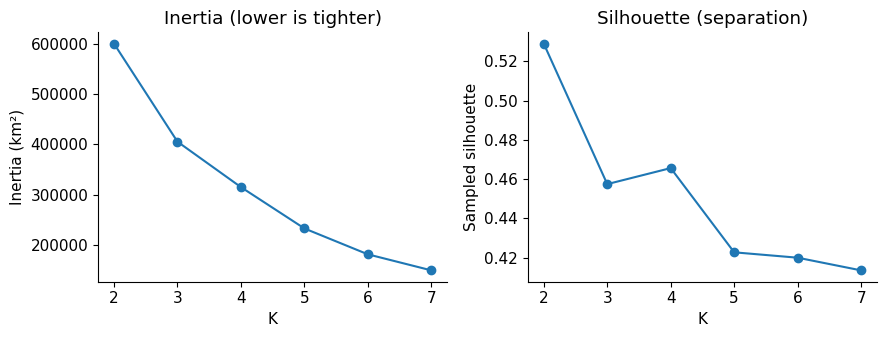

In [ ]:
#@title 🧪 EXPERIMENT A: CHANGING THE NUMBER OF GROUPS { run: "auto" }

# We've randomized these sliders to encourage exploration! Adjust them to find the best range.
MIN_K = 2 #@param {type:"slider", min:2, max:5, step:1}
MAX_K = 10 #@param {type:"slider", min:6, max:10, step:1}

k_values = list(range(MIN_K, MAX_K + 1))
trials = {5: result} # Keep the original K=5 result

for k in k_values:
    if k not in trials:
        try:
            trials[k] = investigate(k=k)
        except Exception:
            pass

rows = []
baseline_center = result['model'].cluster_centers_[result['candidate']]

# Create a table showing the results for each K
for k in k_values:
    if k in trials:
        run = trials[k]
        center = run['model'].cluster_centers_[run['candidate']]
        row = run['summary'].loc[run['candidate']]
        rows.append({'K': k, 'inertia': run['inertia'], 'silhouette': run['silhouette'],
                     'candidate_night_enrichment': row.night_enrichment,
                     'candidate_night_dates': row.distinct_night_dates,
                     'shift_from_K5_km': np.linalg.norm(center - baseline_center)})

experiment_table = pd.DataFrame(rows).set_index('K')
display(experiment_table.round(3))

# Draw charts to visualize the differences
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
experiment_table['inertia'].plot(marker='o', ax=axes[0], title='Inertia (lower is tighter)')
experiment_table['silhouette'].plot(marker='o', ax=axes[1], title='Silhouette (separation)')
axes[0].set_ylabel('Inertia (km²)')
axes[1].set_ylabel('Sampled silhouette')
for ax in axes: ax.set_xticks(experiment_table.index)
fig.tight_layout()
plt.show()

### Interpreting Experiment A: Changing K

Let's break down what the table and graphs above mean for finding Spidey's home:

*   **`K`**: This is the number of groups (clusters) we told the computer to find.
*   **`inertia`**: Think of this as how "snug" the points are inside their group. A *smaller* number means the points are closer to their group's center. As you increase `K`, `inertia` usually goes down because you have more centers to choose from.
*   **`silhouette`**: This score tells us how well-separated the groups are from each other. A score closer to 1 means the groups are very distinct and clear.
*   **`shift_from_K5_km`**: This is a key clue! It tells you how much the "candidate home base" moved when you changed `K` (the number of groups) compared to our first run with `K=5`.
    *   If `shift_from_K5_km` is small (like less than 1 km), it means the location is pretty stable. This is good!
    *   If `shift_from_K5_km` is large, it means the location jumps around a lot when you change `K`. This makes the location less reliable as a "home base" guess.

**Your thoughts, Detective:**
1.  Did the candidate location stay mostly in the same spot when you tried different `K` values?
2.  Does a lower `inertia` (snugger groups) always lead to a better home guess, or do you need to balance it with `silhouette` (clearer groups) and the `shift` (stable location)?

#### Task B • The nighttime window (sensitivity, not score-chasing)
Spidey might not head home exactly at midnight. Try another window (for example **2 AM–4 AM**) and/or another K.

**Still your only goal:** a home estimate that is as accurate as the evidence supports—**not** the maximum Night Enrichment.

When you change settings:
1. Write down your `MY_K`, `NIGHT_START`, and `NIGHT_END` first.
2. Ask: did the candidate stay nearby? Is enrichment still **> 1**? Is the cluster still **eligible**?
3. Explain failures too (enrichment drops, pin jumps, eligibility fails). That is good detective work.

A narrower window can raise enrichment by focusing on fewer hours even when the home guess is no better.


,all_reports,night_reports,distinct_night_dates,night_share,all_share,night_enrichment,eligible,latitude,longitude
cluster,,,,,,,,,
1,15901,4210,383,0.374,0.262,1.424,True,40.629,-73.971
3,13610,2286,377,0.203,0.225,0.903,True,40.678,-73.847
0,26932,4189,383,0.372,0.444,0.836,True,40.814,-73.924
2,4165,585,250,0.052,0.069,0.755,True,40.566,-74.158


Shift from guided K=5 candidate: 0.80 km


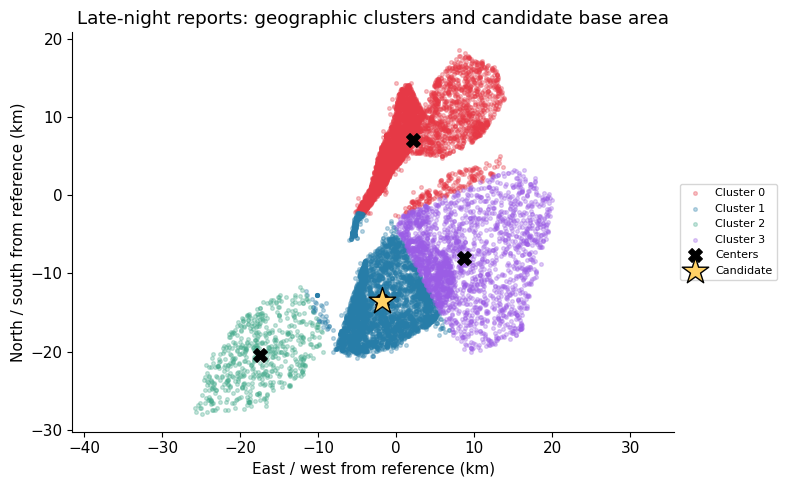

In [ ]:
#@title ⏰ EXPERIMENT B & C: THE CLOCK FORM { run: "auto" }

# These sliders have been randomized to start outside our optimal window. Adjust them to find the true signal!
MY_K = 4 #@param {type:"slider", min:3, max:8, step:1}
NIGHT_START = 23 #@param {type:"slider", min:0, max:23, step:1}
NIGHT_END = 4 #@param {type:"slider", min:1, max:24, step:1}

# Run the investigation using your settings above
my_result = investigate(k=MY_K, start=NIGHT_START, end=NIGHT_END)
display(my_result['summary'].sort_values('night_enrichment', ascending=False).round(3))

my_center = my_result['model'].cluster_centers_[my_result['candidate']]
print(f'Shift from guided K=5 candidate: {np.linalg.norm(my_center - baseline_center):.2f} km')
plot_clusters(my_result)

### Interpreting Experiment B: Changing the Clock and K

Now, look at the table and the map after trying your own `K` and time settings.

*   **`MY_K`**: This is the number of groups you picked.
*   **`NIGHT_START` & `NIGHT_END`**: This is your custom nighttime window (e.g., 2 AM to 4 AM).
*   **`night_enrichment`**: Is this number still greater than 1? If yes, the night pattern still points to this area.
*   **`eligible`**: Is this still `True`? This means there were enough reports and different dates to check this area.
*   **`shift from guided K=5 candidate`**: How many kilometers did your candidate location move from the *original* guess (K=5, 0-5 AM)?

**Your thoughts, Detective:**
1.  When you changed the time or `K`, did the candidate pin jump a lot on the map?
2.  Did the `night_enrichment` stay strong (above 1), or did it get weaker (1 or less)?
This helps you decide how "solid" your guess for Spidey's home base is. A location that doesn't jump much and keeps a strong night enrichment is more reliable.

#### Task C • Final check (read eligible and enrichment separately)
Run the later-period check with the settings stored in `my_result`.

Read the table carefully:
- **`eligible = True`** → enough nighttime reports and dates under the workshop thresholds.
- **`night_enrichment > 1`** → the relative nighttime pattern still points the same way.

You should consider **both**. Eligible alone does **not** mean the pattern held up.

It is OK—and earns full credit for sound reasoning—to conclude the evidence is weak or inconclusive.


In [ ]:
# =====================================================================
# 🏁 FINAL CHECK + EXPORT MAP
# Uses the night window stored in my_result (not whatever NIGHT_* currently are).
# Colab runtimes are temporary—download the HTML if you want to keep it.
# =====================================================================

my_candidate = my_result['candidate']
my_later = cluster_summary(
    my_result['model'],
    later,
    my_result['start'],
    my_result['end'],
)

# Show the final comparison table
display(pd.DataFrame({
    'discovery': my_result['summary'].loc[my_candidate],
    'later check': my_later.loc[my_candidate]
}).T[['night_reports', 'distinct_night_dates', 'night_enrichment', 'eligible']])

elig = bool(my_later.loc[my_candidate, 'eligible'])
enr = float(my_later.loc[my_candidate, 'night_enrichment'])
print(f'Later eligible={elig}; later night_enrichment={enr:.3f}.')
if elig and enr > 1:
    print('Pattern looks repeatable on both checks—still not proof of home.')
elif elig:
    print('Enough later observations, but enrichment ≤ 1 → do not treat eligible as success by itself.')
else:
    print('Later evidence is thin or mixed. "Inconclusive" is a valid final call.')

# Build and show the final map
my_map = build_map(my_result)
display(my_map)

# Save the map as a file, then download it (Colab) so it is not lost with the runtime
map_path = 'my_spidey_candidate_map.html'
my_map.save(map_path)
print(f'Saved {map_path} in the runtime working directory / Files panel.')
print('The HTML still needs internet access to load external map tiles.')
print('File > Save / downloading the .ipynb does NOT keep runtime files forever—download the HTML separately.')
try:
    from google.colab import files
    files.download(map_path)
except ImportError:
    print('Outside Colab: copy the HTML from the working directory yourself.')


### Interpreting Task C: Is the pattern repeatable over time?

Let's look at the final comparison table you just ran. This table helps us see if Spidey's pattern is consistent.

*   **`discovery` column**: This shows the details for our candidate area using the *first half* of the data (what we "discovered" with).
*   **`later check` column**: This shows the details for the *same candidate area*, but using *newer* data from a later time period. This is our "reality check."

For the `later check` column, pay close attention to these two things:
*   **`eligible`**: Is it `True`? If yes, it means there were enough newer reports and different dates in that area to make a fair check.
*   **`night_enrichment`**: Is this number still greater than `1`? If yes, it means the nighttime pattern *still holds* in this area compared to the rest of the city.

**Here's how to make your final call:**
*   If `eligible` is `True` **AND** `night_enrichment` is `> 1`: Great! The pattern looks like it **held** up over time. This makes your "home base" guess much stronger.
*   If `eligible` is `True` **BUT** `night_enrichment` is `<= 1`: Hmm. There was enough new data, but the nighttime pattern **weakened** or disappeared in this area.
*   If `eligible` is `False`: This means there wasn't enough new data to properly check the pattern. Your finding for this period is **inconclusive**.

**Your conclusion, Detective:** Did the nighttime pattern (strong night enrichment) continue for your chosen candidate area in the later time period?

### 🔍 Task D: Zooming In on the Neighborhood (Grid Search)

K-Means gave us wide areas across the city. Now, we want to zoom in on a small, specific neighborhood.

**What this code does (for non-coders):**
We slice the city map into a grid of tiny square boxes (roughly 100 meters wide) by rounding GPS coordinates. Then, we count how many **different days** Spider-Man was spotted in each box. A box that has sightings on many different days is much more suspicious than a box that was only busy on a single night!

Run the cell below to find our top recurring hotspots.

In [ ]:
# =====================================================================
# 🔍 TASK D, PART 1: RANK SMALL MAP CELLS
# =====================================================================
ROUNDING_DECIMALS = 3

# Create rounded coordinates to build our grid boxes
discovery_grid = discovery.copy()
discovery_grid['lat_round'] = discovery_grid['latitude'].round(ROUNDING_DECIMALS)
discovery_grid['lon_round'] = discovery_grid['longitude'].round(ROUNDING_DECIMALS)

# Group sightings by their grid box and count total reports and unique days
hotspots = discovery_grid.groupby(['lat_round', 'lon_round']).agg(
    total_reports=('date', 'size'),
    distinct_dates=('date', 'nunique'),
    median_lat=('latitude', 'median'),
    median_lon=('longitude', 'median')
).reset_index()

# Sort so the spots visited on the most unique days are at the top
hotspots = hotspots.sort_values(['distinct_dates', 'total_reports'], ascending=[False, False]).reset_index(drop=True)

print("Top 5 recurring small map cells:")
display(hotspots[['distinct_dates', 'total_reports', 'median_lat', 'median_lon']].head(5))

### 🎯 Task D, Part 2: Adjust & Refine Your Target

**What this code does (for non-coders):**
We pick one of our top hotspots from the list above and look at all sightings within a short walking distance (e.g., 150 meters). We find the exact mathematical center of those sightings to pin down a highly precise coordinate.

Use the simple form below to choose which rank to inspect and the size of your search circle!

In [ ]:
#@title 🛠️ Hotspot Selection & Radius Form { run: "auto" }

# We randomized the default starting values! Find the right values to pin down Spidey's base.
CANDIDATE_RANK = 4 #@param {type:"slider", min:1, max:5, step:1}
REFINEMENT_RADIUS_M = 350 #@param {type:"slider", min:50, max:500, step:50}

# Convert meters to kilometers for our math
REFINEMENT_RADIUS_KM = REFINEMENT_RADIUS_M / 1000.0

# Get the selected rough candidate coordinates
selected_row = hotspots.iloc[CANDIDATE_RANK - 1]
rough_lat, rough_lon = selected_row['median_lat'], selected_row['median_lon']

# Convert rough center to our local kilometer grid
rough_x = (rough_lon - LON0) * LON_SCALE
rough_y = (rough_lat - LAT0) * KM_PER_DEG

# Find discovery period reports within the chosen circle
discovery['dist_to_rough'] = np.sqrt((discovery['x_km'] - rough_x)**2 + (discovery['y_km'] - rough_y)**2)
nearby_discovery = discovery[discovery['dist_to_rough'] <= REFINEMENT_RADIUS_KM]

# Refine coordinates to the exact middle of these local points
refined_x = nearby_discovery['x_km'].median()
refined_y = nearby_discovery['y_km'].median()

refined_coords = to_latlon(np.array([[refined_x, refined_y]]))[0]
refined_candidate_lat = refined_coords[0]
refined_candidate_lon = refined_coords[1]

print(f"🎯 Selected Hotspot #{CANDIDATE_RANK}")
print(f"📍 Refined coordinate center: ({refined_candidate_lat:.5f}, {refined_candidate_lon:.5f})")

### 🕰️ Task D, Part 3: The Time-Travel Reality Check

**What this code does (for non-coders):**
Does Spider-Man keep returning to this exact coordinate in the *newer* data, or was it just a temporary phase? We count the reports in both time periods to check if the pattern persists.

In [ ]:
# =====================================================================
# 🕰️ TASK D, PART 3: CHECK LATER REPORTS
# =====================================================================
later['dist_to_refined'] = np.sqrt((later['x_km'] - refined_x)**2 + (later['y_km'] - refined_y)**2)
nearby_later = later[later['dist_to_refined'] <= REFINEMENT_RADIUS_KM]

discovery['dist_to_refined'] = np.sqrt((discovery['x_km'] - refined_x)**2 + (discovery['y_km'] - refined_y)**2)
nearby_discovery_refined = discovery[discovery['dist_to_refined'] <= REFINEMENT_RADIUS_KM]

hotspot_evidence = pd.DataFrame({
    'Period': ['Discovery (Past)', 'Later Check (Newer)'],
    'Total Sighting Reports': [len(nearby_discovery_refined), len(nearby_later)],
    'Distinct Days Visited': [nearby_discovery_refined['date'].nunique(), nearby_later['date'].nunique()]
}).set_index('Period')

display(hotspot_evidence)

# Draw a focused local map
plt.figure(figsize=(5, 5))
plt.scatter(discovery['x_km'], discovery['y_km'], s=2, color='gray', alpha=0.05, label='City Sightings')
plt.scatter(nearby_discovery_refined['x_km'], nearby_discovery_refined['y_km'], color='#43aa8b', s=15, label='Discovery (Local)')
plt.scatter(nearby_later['x_km'], nearby_later['y_km'], color='#f8961e', s=15, label='Later (Local)')
plt.scatter([refined_x], [refined_y], color='red', marker='*', s=250, edgecolor='black', label='Target Center')

plt.xlim(refined_x - 0.5, refined_x + 0.5)
plt.ylim(refined_y - 0.5, refined_y + 0.5)
plt.title("Target Area Zoom-In (1km Box)")
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

**Interpretation Questions:**
1. Does this small area appear repeatedly across many dates?
2. Does the same fixed location continue to receive reports in the later period?

---
## 📋 10 • The Detective's Final Submission

Run the cell below to print a summary of your investigation, then answer the final analysis questions.

For the workshop, the primary suspected base latitude and longitude will be your answer!

In [ ]:
# --- AUTOMATED EXECUTIVE SUMMARY ---
discovery_enrichment = my_result['summary'].loc[my_result['candidate']]['night_enrichment']
later_enrichment = my_later.loc[my_result['candidate']]['night_enrichment']
elig_later = bool(my_later.loc[my_candidate, 'eligible'])

print("===========================================================")
print("               🕵️ SPIDEY TRACKER EXECUTIVE SUMMARY          ")
print("===========================================================")
print(f"1. Primary Suspected Base Coordinates : ({refined_candidate_lat:.5f}, {refined_candidate_lon:.5f})")
print(f"2. Model Configuration                 : K={my_result['model'].n_clusters} clusters, night window {my_result['start']}:00 - {my_result['end']}:00")
print(f"3. Geographic Night Enrichment         : Discovery={discovery_enrichment:.2f}x | Later Check={later_enrichment:.2f}x")
print(f"4. Local Hotspot Stability             : {len(nearby_discovery_refined)} sightings in Past -> {len(nearby_later)} in Newer")
print(f"5. Verification Pattern Check          : Later Eligible={elig_later} | Enrichment > 1={later_enrichment > 1}")
print("===========================================================")

### 📝 Detective's Assessment (Fill in the Blanks)

**Is the pattern repeatable over time?**
* The pattern (held / mixed / did not hold): **`_________`**
*(Hint: If both 'Eligible' and 'Enrichment > 1' are True, it **held**).*

**Detective's final call on confidence:**
* Overall, our evidence for this home location is (strong / mixed / insufficient): **`_________`**
* One non-home explanation we must consider is **`__________________________________________________________`**.
*(Example: Spidey has a favorite local patrol route, more witnesses are active here at night, or it's a simulation artifact).*

In [ ]:
# --- Report Section 2: Model Configuration ---
print(f"Model Configuration: K={my_result['model'].n_clusters} clusters")
print(f"Nighttime Window: {my_result['start']}:00 to {my_result['end']}:00")

### ⚙️ Model Configuration
We utilized $K$=**___** clusters, focusing on the nighttime window of **___**:00 to **___**:00.

In [ ]:
# --- Report Section 3: Observed Nighttime Enrichment ---
discovery_enrichment = my_result['summary'].loc[my_result['candidate']]['night_enrichment']
later_enrichment = my_later.loc[my_result['candidate']]['night_enrichment']
print(f"Discovery Nighttime Enrichment: {discovery_enrichment:.2f}x")
print(f"Later Check Nighttime Enrichment: {later_enrichment:.2f}x")

### 🌃 Observed Nighttime Enrichment
Discovery = **___**× ; Later check = **___**×.
In plain English, enrichment compares this area's nighttime share of reports to the citywide nighttime share (it is **not** "how many times busier at night than during the day").

In [ ]:
# --- Report Section 3.5: Local Hotspot Evidence ---
print(f"Discovery reports (150m): {len(nearby_discovery_refined)}")
print(f"Discovery distinct dates: {nearby_discovery_refined['date'].nunique()}")
print(f"Later reports (150m): {len(nearby_later)}")
print(f"Later distinct dates: {nearby_later['date'].nunique()}")


### 📍 Local Hotspot Evidence
Discovery reports within 150m: **___** (across **___** dates).
Later reports within 150m: **___** (across **___** dates).


In [ ]:
# --- Report Section 4: Validation ---
elig_later = bool(my_later.loc[my_candidate, 'eligible'])
enr_later_gt_1 = bool(my_later.loc[my_candidate, 'night_enrichment'] > 1)
print(f"Later period eligible: {elig_later}")
print(f"Later period enrichment > 1: {enr_later_gt_1}")

### ✅ Validation
Later period — eligible? (yes/no): **___**. Enrichment > 1? (yes/no): **___**.
Overall, the pattern (held / mixed / did not hold): **______**.
(Hint: If both 'eligible' is True AND 'enrichment > 1' is True, it "held." If eligible is True but enrichment <= 1, it's "mixed." If eligible is False, it "did not hold.")

### 🕵️‍♀️ Detective's Assessment
Combine the broad K-Means lesson, the refined recurring-location result, and the later-period check to evaluate the evidence:

Overall, our evidence is (strong / mixed / insufficient): **______**.

One non-home explanation we must consider is **__________________________________________________________**.
(Example non-home explanations: Spidey patrols there, more people look for him there at night, or it could be random noise.)


In [ ]:
# --- Report Section 5: Secondary Mission (Classifier Accuracy) ---
# To find the accuracy of the decision tree classifier, please refer to the output of cell 5da83137.
# Look under the 'decision tree' row and 'accuracy' column in the table displayed by that cell.
# You will need to manually input this value into the markdown cell below.
print("Please manually refer to the output of cell 5da83137 for the classifier accuracy.")

### 🎯 Secondary Mission: Verification Classifier
Our verification classifier achieved **___**% accuracy (compare to the ~63% always-verified baseline).
Remember: accuracy is overall correctness, not "percent of unreliable reports caught."

## 11 • Case Closed (For Now)

**Congratulations, Detective!**

You've just completed a full Machine Learning workflow:
1. **Data Engineering:** You flattened coordinates into local km and cleaned messy reports.
2. **Supervised Learning:** You built a Decision Tree to predict verification labels (a separate demo from the map).
3. **Unsupervised Learning:** You used K-Means to partition late-night points and ranked candidate areas by night enrichment.
4. **Sensitivity analysis:** You experimented with K and the night window to see how stable the home guess is.
5. **Local hotspot detection:** you zoomed in on a small location that repeated across many dates.

**Next Steps:** Share your map with your fellow detectives. Did you all find the same candidate area, or different ones?

**Saving work:** Use the notebook UI to save the `.ipynb`, and **download** `my_spidey_candidate_map.html` from the Files panel (or via the download call above). Colab runtimes are temporary; saving the notebook alone does not keep runtime files forever. The HTML still needs internet access for map tiles.


## 🕵️  The Missing Detective Tool: Regression

We covered **Classification** (which label?) and **Clustering** (where are the groups?). Another major tool is **Regression**.

### What is Regression?
Regression predicts a **numerical quantity** (including expected counts), not a category label.

### Where would it fit in our Spidey Mission?
If we wanted to expand this tracker, we could use Regression to predict:
1. **Response Time:** "Based on the traffic and the hour, how many *minutes* until Spidey arrives?"
2. **Distance:** "Based on the web-fluid residue found, how many *kilometers* did he travel?"
3. **Crowd Size:** "If there is a sighting at Times Square at 5 PM, how many *witnesses* should we expect?"

**The Difference:**
* **Classification:** Verified or not verified?
* **Regression:** How much? How long? How far? How many?


## References and further reading

- **Dataset:** [Umut Tuygurr, Spidey Tracker: Spiderman Dataset](https://www.kaggle.com/datasets/umuttuygurr/spidey-tracker-spiderman-dataset/data), Kaggle dataset version 2 retrieved September 5, 2026. Internal folder is named `v1`; its README calls the release v1.0.0. Public metadata lists **CC0: Public Domain**. The release includes a `README.md`, `DATA_DICTIONARY.md`, and `manifest.json`. The sightings CSV contains **86,631 rows and 33 columns**. The pinned CSV hash is checked by the loader. The publisher describes the data as simulated / synthetic for the open-ended base investigation.
- **Mission mapping:** publisher Mission 01 → binary supervised demo; publisher Mission 05 → open-ended hidden-base investigation. The night-enrichment ranking, chronological check, and teaching exercises are workshop additions, not a publisher-supplied home solution. The publisher's random-forest baseline is a different model; its reported score is not our tree's score.
- [Colab introduction](https://colab.research.google.com/notebooks/intro.ipynb).
- [Colab FAQ (temporary runtimes)](https://research.google.com/colaboratory/faq.html).
- [scikit-learn: K-Means and clustering](https://scikit-learn.org/stable/modules/clustering.html#k-means).
- [scikit-learn: DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).
- [scikit-learn: common pitfalls (evaluation / leakage)](https://scikit-learn.org/stable/common_pitfalls.html).
- [scikit-learn: silhouette score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html).

### Troubleshooting
- **NameError:** run setup and preceding cells in order. **Runtime reset:** rerun setup and the main path.
- **Kaggle unavailable / hash mismatch:** upload a backup ZIP/CSV if your instructor provided one, or the pinned Kaggle ZIP / `sightings.csv`; no credentials are required for the upload route.
- **Map blank:** use the static coordinate plot. Tiles/scripts require internet; map rendering is separate from model training.
- **Keep your map:** download `my_spidey_candidate_map.html` from the Files panel; saving the notebook alone does not preserve runtime files.
